# Homework 2

### Disclaimer

The author acknowledges the use of Claude in the preparation or completion of this assignment. Claude was used in the following way(s) in this assignment: debugging across blocks of code and reviewing assignment to provide feedback on work completed.


In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import nfl_data_py as nfl
import sportsdataverse as sdv

## Question 1

In [137]:
# load the 2022-2025 season
plays_df_polars = sdv.cfb.load_cfb_pbp(seasons=[2022, 2023, 2024, 2025], return_as_pandas=False)
games_df_polars = sdv.cfb.load_cfb_schedule(seasons=[2022, 2023, 2024, 2025], return_as_pandas=False)

# convert the polar files to pandas dataframe
pbp_2025_raw = plays_df_polars.to_pandas(use_pyarrow_extension_array=False)
games_df=games_df_polars.to_pandas(use_pyarrow_extension_array=False)
print("\n".join(games_df.columns))

# filter down game metadata to isolate the home/away division tags
games_meta = games_df[['game_id', 'home_division', 'away_division','home_conference','away_conference']]

# merge the division tags onto your play-by-play data
final_pbp = pd.merge(pbp_2025_raw, games_meta, on='game_id', how='left')


game_id
season
week
season_type
start_date
start_time_tbd
completed
neutral_site
conference_game
attendance
venue_id
venue
home_id
home_team
home_division
home_conference
home_points
home_post_win_prob
home_pregame_elo
home_postgame_elo
away_id
away_team
away_division
away_conference
away_points
away_post_win_prob
away_pregame_elo
away_postgame_elo
excitement_index
highlights
notes


In [138]:
# filter to fbs vs fbs games
pbp_2022_25 = final_pbp[
    (final_pbp['home_division'] == 'fbs') & 
    (final_pbp['away_division'] == 'fbs')
].copy()

pbp_2022_2025 = pbp_2022_25.rename(columns={'statYardage': 'yards_gained'})

print(f"Dataset successfully loaded. Dimensions: {pbp_2022_2025.shape}")


Dataset successfully loaded. Dimensions: (534148, 481)


In [139]:
def process_next_score_data(df):
    # Base filtering
    filtered = df[
        (df['seasonType'] == 2) &
        (df['EP_start'].notna()) &
        (df['pos_team'].notna()) &
        (~df['lead_play_type'].isin(['Two Point Rush', 'Two Point Pass']))
    ].copy()

    # Step A: Identify home scoring events
    def calc_home_score_event(row):
        if row['touchdown'] == 1 and row['offense_score_play'] == 1:
            if row['is_home']:
                return 7.0
            else:
                return -7.0
        elif row['touchdown'] == 1 and row['defense_score_play'] == 1:
            if not row['is_home']:  # defense is home
                return 7.0
            else:
                return -7.0
        elif row['fg_made'] == 1 and row['is_home']:
            return 3.0
        elif row['fg_made'] == 1 and not row['is_home']:
            return -3.0
        elif row['safety'] == 1 and not row['is_home']:  # defense is home
            return 2.0
        elif row['safety'] == 1 and row['is_home']:
            return -2.0
        return np.nan


    filtered['home_scoring_event'] = filtered.apply(calc_home_score_event, axis=1)

    # Step B: Backfill within game_id and game_half
    filtered['home_scoring_event'] = (
        filtered.groupby(['game_id', 'half'])['home_scoring_event']
        .bfill()
    )

    # Step C: Fill remaining missing with 0
    filtered['home_scoring_event'] = filtered['home_scoring_event'].fillna(0)

    # Step D: Convert to possession team perspective
    filtered['pts_next_score'] = np.where(
        filtered['is_home'],
        filtered['home_scoring_event'],
        -filtered['home_scoring_event']
    )

    # Apply garbage time filter
    filtered = filtered[
        (filtered['wp_before'].notna()) &
        (filtered['wp_before'] >= 0.05) &
        (filtered['wp_before'] <= 0.95)
    ].copy()

    return filtered

pbp_filtered = process_next_score_data(pbp_2022_2025)


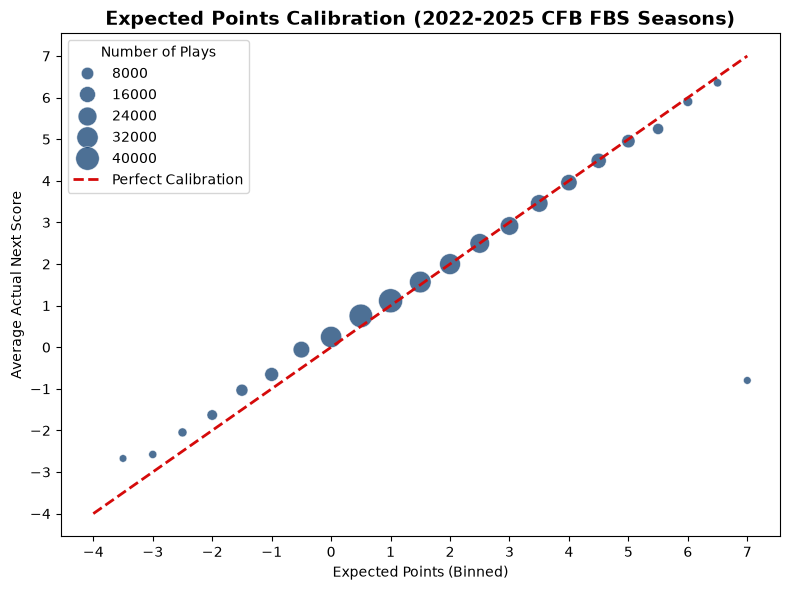

In [140]:
def plot_calibration(df, bin_width=0.5, min_plays=50, title_suffix="2022-2025 CFB FBS Seasons"):
    df_copy = df.copy()
    df_copy['ep_bin'] = (df_copy['EP_start'] / bin_width).round() * bin_width

    cal_data = df_copy.groupby('ep_bin').agg(
        actual_pts=('pts_next_score', 'mean'),
        plays=('pts_next_score', 'count')
    ).reset_index()

    cal_data = cal_data[cal_data['plays'] >= min_plays]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=cal_data, x='ep_bin', y='actual_pts', size='plays', 
        sizes=(30, 300), color='#013369', alpha=0.7, ax=ax
    )
    ax.plot([-4, 7], [-4, 7], linestyle='--', color='#D50A0A', linewidth=2, label='Perfect Calibration')
    
    ax.set_xticks(range(-4, 8))
    ax.set_yticks(range(-4, 8))
    ax.set_title(f"Expected Points Calibration ({title_suffix})", fontweight='bold', fontsize=14)
    ax.set_xlabel("Expected Points (Binned)")
    ax.set_ylabel("Average Actual Next Score")
    ax.legend(title="Number of Plays", loc="upper left")
    plt.tight_layout()
    plt.show()

plot_calibration(pbp_filtered)


Overall, both the college football and NFL models roughly follow the calibration line. However, several differences point to more variance in behavior in college football than in the NFL. First, NFL model plays follow the perfect calibration line more closely, whereas in the college football model, up to 2 expected points, plays fall above the calibration line. Additionally, the range of plays is wider in college football, extending from -3.5 to 7 expected points, whereas the NFL range is -3 to 6.5. Since the dots are small for these values, it indicates that college football has more extreme outliers than the NFL. Finally, the biggest outlier across all charts is college football's expected points of 7 where it falls significantly below the perfect calibration line at around -1 actual next score. This differs from the NFL because, for the value closest to 7 on the chart (6.5), the actual average score is a little over 6. This may indicate that few plays reach an expected points value of 7, and these plays are prone to unexpected situations like turnovers. Further analysis can determine whether these conclusions stem from more chaotic situations in college football or from the talent gap being much wider than in the NFL.  

## Question 2
2.  (25 points) In class we talked about the 3rd and X model. Using data from the most recent 5 NFL seasons, fit the model described in class and in a well written paragraph evaluate the claim that \`\`all teams in the NFL are equally good at making 3rd and X.'' Explain any choices that you made regarding the data and the models.


In [141]:
pbp = nfl.import_pbp_data([2021,2022,2023,2024,2025])

2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.


In [142]:
model_data = pbp[
    pbp['half_seconds_remaining'].notna() &
    pbp['half_seconds_remaining'].notna() &
    pbp['yardline_100'].notna() &
    pbp['ydstogo'].notna() &
    pbp['goal_to_go'].notna() &
    (pbp['ydstogo'] > 0)
].copy()

model_data_nfl = model_data[
    (pbp['down'] == 3) &
    (pbp['season_type'] == 'REG') &
    (pbp['wp'] >= 0.05) & (pbp['wp'] <= 0.95) &
    (pbp['half_seconds_remaining'] >= 30)
].copy()

model_data_nfl['third_down_converted'] = (model_data_nfl['third_down_converted'] == 1).astype(int)
model_data_nfl['log_ytg'] = np.log(model_data_nfl['ydstogo'])
model_data_nfl['home_field'] = (model_data_nfl['posteam'] == model_data_nfl['home_team']).astype(int)


/var/folders/jr/vc14h5lx5gz41584rmkfgl380000gn/T/ipykernel_66950/3589618953.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  model_data_nfl = model_data[


In [143]:
base_model = smf.logit("third_down_converted ~ log_ytg", data=model_data_nfl).fit()
print(base_model.summary())


Optimization terminated successfully.
         Current function value: 0.605816
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                31175
Model:                            Logit   Df Residuals:                    31173
Method:                             MLE   Df Model:                            1
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.08098
Time:                          12:16:17   Log-Likelihood:                -18886.
converged:                         True   LL-Null:                       -20551.
Covariance Type:              nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7809      0.026     29.489      0.000       0.729       0.833
log_ytg      

In [144]:
team_model = smf.logit("third_down_converted ~ log_ytg + C(posteam)", data=model_data_nfl).fit()
print(team_model.summary())


Optimization terminated successfully.
         Current function value: 0.604115
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                31175
Model:                            Logit   Df Residuals:                    31142
Method:                             MLE   Df Model:                           32
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.08356
Time:                          12:16:17   Log-Likelihood:                -18833.
converged:                         True   LL-Null:                       -20551.
Covariance Type:              nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.7662      0.076     10.133      0.000       0.618     

In [145]:
print(model_data_nfl.columns[model_data_nfl.columns.str.contains('home', case=False)].tolist())


['home_team', 'home_timeouts_remaining', 'total_home_score', 'total_home_epa', 'total_home_rush_epa', 'total_home_pass_epa', 'total_home_comp_air_epa', 'total_home_comp_yac_epa', 'total_home_raw_air_epa', 'total_home_raw_yac_epa', 'home_wp', 'vegas_home_wpa', 'home_wp_post', 'vegas_home_wp', 'total_home_rush_wpa', 'total_home_pass_wpa', 'total_home_comp_air_wpa', 'total_home_comp_yac_wpa', 'total_home_raw_air_wpa', 'total_home_raw_yac_wpa', 'home_score', 'home_coach', 'home_opening_kickoff', 'home_field']


In [146]:
full_model = smf.logit("third_down_converted ~ log_ytg + C(posteam) + C(defteam) + home_field", data=model_data_nfl).fit()
print(full_model.summary())

Optimization terminated successfully.
         Current function value: 0.603470
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                31175
Model:                            Logit   Df Residuals:                    31110
Method:                             MLE   Df Model:                           64
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.08454
Time:                          12:16:17   Log-Likelihood:                -18813.
converged:                         True   LL-Null:                       -20551.
Covariance Type:              nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.8091      0.107      7.559      0.000       0.599     

To build my model, I filtered to regular-season games only, excluded garbage time based on win probability, and excluded the end of the half. I did not filter out plays in the red zone because classwork showed the red zone is arbitrary, and I believe including it strengthens or weakens a team's effect on third-down conversions. I filtered these to ensure the sample reflected what most games look like and focused on active playing time rather than teams running the clock. I ran three models: one with log yards to go, one with log yards to go and offensive team, and one with log yards to go, offensive and defensive teams, and home-field advantage. Across all models, log yards to go was the strongest predictor, with a coefficient of ~-0.83 and a p-value of 0. Overall, team coefficients were not significant for either offense or defense, as most teams had high p-values. However, with 64 team coefficients, it is statistically likely that around 3 coefficients would appear significant purely by chance; since the overwhelming majority of these team p-values were high, the feature itself is not significant. That said, the model supports the conclusion that all NFL teams are roughly equally good at 3rd and X, but conversion probability is driven by yards to go, not team identity

## Question 3
3.  (20 points) Repeat #2 above, using college football data. Explain any choices that you made regarding the data and the models.


In [147]:
# load the 2021-2025 season
plays_df_polars = sdv.cfb.load_cfb_pbp(seasons=[2021, 2022, 2023, 2024, 2025], return_as_pandas=False)
games_df_polars = sdv.cfb.load_cfb_schedule(seasons=[2021, 2022, 2023, 2024, 2025], return_as_pandas=False)

# convert the polar files to pandas dataframe
pbp_2025_raw = plays_df_polars.to_pandas(use_pyarrow_extension_array=False)
games_df=games_df_polars.to_pandas(use_pyarrow_extension_array=False)
print("\n".join(games_df.columns))

# filter down game metadata to isolate the home/away division tags
games_meta = games_df[['game_id', 'home_division', 'away_division','home_conference','away_conference']]

# merge the division tags onto your play-by-play data
final_pbp = pd.merge(pbp_2025_raw, games_meta, on='game_id', how='left')


game_id
season
week
season_type
start_date
start_time_tbd
completed
neutral_site
conference_game
attendance
venue_id
venue
home_id
home_team
home_division
home_conference
home_points
home_post_win_prob
home_pregame_elo
home_postgame_elo
away_id
away_team
away_division
away_conference
away_points
away_post_win_prob
away_pregame_elo
away_postgame_elo
excitement_index
highlights
notes


In [148]:
model_data = final_pbp[
    final_pbp['start.adj_TimeSecsRem'].notna() &
    final_pbp['start.yardsToEndzone'].notna() &
    final_pbp['start.distance'].notna() &
    final_pbp['goal_to_go'].notna() &
    (final_pbp['start.distance'] > 0)
].copy()

model_data_cfb = model_data[
    (model_data['down'] == 3) &
    (model_data['seasonType'] == 2) &
    (model_data['wp_before'] >= 0.05) & (model_data['wp_before'] <= 0.95) &
    (model_data['start.adj_TimeSecsRem'] >= 30) &
    (model_data['start.distance'] > 0)
].copy()

model_data_cfb['offense_conference'] = np.where(
    model_data_cfb['is_home'],
    model_data_cfb['home_conference'],
    model_data_cfb['away_conference']
)
model_data_cfb['defense_conference'] = np.where(
    model_data_cfb['is_home'],
    model_data_cfb['away_conference'],
    model_data_cfb['home_conference']
)

model_data_cfb['third_down_converted'] = (model_data_cfb['first_down_created'] == 1).astype(int)
model_data_cfb['log_ytg'] = np.log(model_data_cfb['start.distance'])
model_data_cfb['home_field'] = model_data_cfb['is_home'].astype(int)

In [149]:
base_model = smf.logit("third_down_converted ~ log_ytg", data=model_data_cfb).fit()
print(base_model.summary())


Optimization terminated successfully.
         Current function value: 0.574285
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                81459
Model:                            Logit   Df Residuals:                    81457
Method:                             MLE   Df Model:                            1
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.06772
Time:                          12:18:13   Log-Likelihood:                -46781.
converged:                         True   LL-Null:                       -50179.
Covariance Type:              nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4283      0.017     25.216      0.000       0.395       0.462
log_ytg      

In [150]:
team_model = smf.logit("third_down_converted ~ log_ytg + C(offense_conference)", data=model_data_cfb).fit()
print(team_model.summary())


Optimization terminated successfully.
         Current function value: 0.573957
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                81459
Model:                            Logit   Df Residuals:                    81429
Method:                             MLE   Df Model:                           29
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.06825
Time:                          12:18:13   Log-Likelihood:                -46754.
converged:                         True   LL-Null:                       -50179.
Covariance Type:              nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                   

In [151]:
full_model = smf.logit("third_down_converted ~ log_ytg + C(offense_conference) + C(defense_conference) + home_field", data=model_data_cfb).fit()
print(full_model.summary())

Optimization terminated successfully.
         Current function value: 0.573511
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                81459
Model:                            Logit   Df Residuals:                    81400
Method:                             MLE   Df Model:                           58
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.06897
Time:                          12:18:14   Log-Likelihood:                -46718.
converged:                         True   LL-Null:                       -50179.
Covariance Type:              nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                   

In [152]:
model_data_fbs = model_data_cfb[
    (model_data_cfb['home_division'] == 'fbs') & 
    (model_data_cfb['away_division'] == 'fbs')
].copy()

base_fbs = smf.logit("third_down_converted ~ log_ytg", data=model_data_fbs).fit()
homefield_fbs = smf.logit("third_down_converted ~ log_ytg + home_field", data=model_data_fbs).fit()
full_fbs = smf.logit("third_down_converted ~ log_ytg + C(offense_conference) + C(defense_conference) + home_field", data=model_data_fbs).fit()
print(full_fbs.summary())


Optimization terminated successfully.
         Current function value: 0.573990
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.573908
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.573626
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                76308
Model:                            Logit   Df Residuals:                    76285
Method:                             MLE   Df Model:                           22
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.06882
Time:                          12:18:14   Log-Likelihood:                -43772.
converged:                         True   LL-Null:                       -47007.
Covariance Type:              nonrobust   LLR p-value:                     0.000
                                              

In [153]:
model_data_fbs = model_data_cfb[
    (model_data_cfb['home_division'] == 'fcs') & 
    (model_data_cfb['away_division'] == 'fcs')
].copy()

base_fbs = smf.logit("third_down_converted ~ log_ytg", data=model_data_fbs).fit()
full_fbs = smf.logit("third_down_converted ~ log_ytg + C(offense_conference) + C(defense_conference) + home_field", data=model_data_fbs).fit()
print(full_fbs.summary())


Optimization terminated successfully.
         Current function value: 0.613596
         Iterations 5
         Current function value: 0.604479
         Iterations: 35
                            Logit Regression Results                            
Dep. Variable:     third_down_converted   No. Observations:                 1050
Model:                            Logit   Df Residuals:                     1031
Method:                             MLE   Df Model:                           18
Date:                  Sat, 29 Aug 2026   Pseudo R-squ.:                 0.05420
Time:                          12:18:14   Log-Likelihood:                -634.70
converged:                        False   LL-Null:                       -671.08
Covariance Type:              nonrobust   LLR p-value:                 1.539e-08
                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

/Users/hannahw/school/ITCS5010/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The model I chose to represent all of college football is a logistic regression model with the features log yards to go and home-field advantage. To determine my model, similarly to the NFL models, I ran three different models. One with just yards to go, one with yards to go and offensive conference, and one with yards to go, offensive conference, defensive conference, and home-field advantage. Instead of using specific teams, I used conference for college football, since there are significantly more teams and this would make analysis more difficult. For both offensive and defensive conferences, most p-values are not significant, which indicates that conference is not a good predictor of third-down conversion. It is interesting that more defensive conferences were significant than offensive conferences. I ran one overall college model with combined FBS and FCS data as well as individual FBS and FCS data. Because of the small sample size and wide conference spread, the FCS model is unreliable. For the FBS model, the results were very similar to the overall college football model, with the most conferences not being significant. Home-field advantage and log yards to go are the most important features. In the all-conference model, the significant coefficients were the FCS conferences, and in the FBS-only model, it was the non-Power 4 conferences, indicating talent gaps driving differences. However, unlike for the NFL data, home-field advantage is a significant predictor and can affect third-down conversions in college football. I agree that all conferences are equally good at 3rd and X; however, some conferences are better at minimizing yards to go on their third downs and the differences are driven by talent gaps in competition rather than conference identity. 